# Proyecto 1: Predicción de GRD - Hospital El Pino
Este pipeline incluye el Análisis Exploratorio de Datos (EDA) y la configuración para el entrenamiento de varios modelos de Machine Learning y Deep Learning.

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, accuracy_score, top_k_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

# XGBoost y Random Forest
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# cuML para aceleración por GPU

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Lista global para almacenar el resumen de los mejores modelos evaluados en el conjunto de prueba
resumen_modelos = []

## 2. Carga de Datos y Preprocesamiento

In [8]:
# Cargar el dataset
df = pd.read_csv('dataset_elpino.csv', sep=';')
df.replace('-', np.nan, inplace=True)
# FILTRO AGREGADO: Filtrar clases con muy pocos registros para evitar errores en Cross Validation y XGBoost
conteo_clases = df['GRD'].value_counts()
clases_validas = conteo_clases[conteo_clases >= 4].index
df = df[df['GRD'].isin(clases_validas)].copy()
print(f"Se eliminaron {(conteo_clases < 4).sum()} clases poco frecuentes.")
# Unificar diagnósticos y procedimientos
diag_cols = [col for col in df.columns if col.startswith('Diag')]
proc_cols = [col for col in df.columns if col.startswith('Proced')]
df['All_Diagnostics'] = df[diag_cols].apply(lambda row: ' '.join(row.dropna().astype(str)), axis=1)
df['All_Procedures'] = df[proc_cols].apply(lambda row: ' '.join(row.dropna().astype(str)), axis=1)
# Seleccionar variables finales
X_text = df['All_Diagnostics'] + " " + df['All_Procedures']
X_num = df[['Edad en años']]
X_cat = df[['Sexo (Desc)']]
y = df['GRD']
# Codificar Y a numérico (Label Encoding)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
# Split Train/Test
X_train_txt, X_test_txt, X_train_num, X_test_num, X_train_cat, X_test_cat, y_train, y_test = train_test_split(
    X_text, X_num, X_cat, y_encoded, test_size=0.2, random_state=42
)
print(f"Entrenamiento: {len(y_train)} muestras, Prueba: {len(y_test)} muestras")
# Construcción del preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=1000), 'All_text'),
        ('num', StandardScaler(), ['Edad en años']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Sexo (Desc)'])
    ])
# Dataframes finales para inyectar en los pipelines
X_train_df = pd.DataFrame({'All_text': X_train_txt, 'Edad en años': X_train_num['Edad en años'], 'Sexo (Desc)': X_train_cat['Sexo (Desc)']})
X_test_df = pd.DataFrame({'All_text': X_test_txt, 'Edad en años': X_test_num['Edad en años'], 'Sexo (Desc)': X_test_cat['Sexo (Desc)']})

def evaluar_modelo(nombre, search_cv, X_test, y_test):
    """Extrae el mejor modelo, genera predicciones en Test y calcula las métricas solicitadas."""
    best_model = search_cv.best_estimator_
    y_pred = best_model.predict(X_test)

    f1_mac = f1_score(y_test, y_pred, average='macro')
    f1_wei = f1_score(y_test, y_pred, average='weighted')

    # Intento de cálculo de Top-5 Accuracy
    try:
        y_prob = best_model.predict_proba(X_test)
        top5_acc = top_k_accuracy_score(y_test, y_prob, k=5, labels=best_model.classes_)
    except Exception as e:
        # Fallback por si usamos decision_function o el modelo no admite predict_proba
        try:
            y_prob = best_model.decision_function(X_test)
            top5_acc = top_k_accuracy_score(y_test, y_prob, k=5, labels=best_model.classes_)
        except Exception as e:
            top5_acc = np.nan
            print(f"Advertencia: No se pudo calcular el Top-5 Accuracy para {nombre}: {e}")

    print(f"\nResultados en el Test Set para {nombre}:")
    print(f" - F1 Macro:      {f1_mac:.4f}")
    print(f" - F1 Weighted:   {f1_wei:.4f}")
    print(f" - Top-5 Accuracy:{top5_acc:.4f}\n")

    # Guardamos exclusivamente las métricas de Test en el resumen final
    resumen_modelos.append({
        'Modelo': nombre,
        'Mejores Params': str(search_cv.best_params_),
        'F1 Macro (Test)': f1_mac,
        'F1 Weighted (Test)': f1_wei,
        'Top-5 Accuracy (Test)': top5_acc
    })

Se eliminaron 163 clases poco frecuentes.
Entrenamiento: 11423 muestras, Prueba: 2856 muestras


## 4. Modelos Clásicos con Búsqueda de Hiperparámetros

In [10]:
# --- 3.1 XGBoost Classifier (GPU) ---
print("Iniciando Entrenamiento: XGBoost (GPU)...")

# Calcular sample weights para balancear clases
sample_weights = compute_sample_weight('balanced', y_train)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    # Corrección para versiones modernas de XGBoost en Colab:
    ('clf', XGBClassifier(tree_method='hist', device='cuda', random_state=42))
])

xgb_params = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [10, 20, 50]
}

# n_jobs=1 para evitar que GridSearchCV paralelice en CPU mientras usamos GPU
grid_xgb = GridSearchCV(xgb_pipeline, xgb_params, cv=3, scoring='f1_macro', n_jobs=1, verbose=1)
grid_xgb.fit(X_train_df, y_train, clf__sample_weight=sample_weights)

evaluar_modelo('XGBoost (GPU)', grid_xgb, X_test_df, y_test)

evaluar_modelo('XGBoost (GPU)', grid_xgb, X_test_df, y_test)

Iniciando Entrenamiento: XGBoost (GPU)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [01:50:57] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Resultados en el Test Set para XGBoost (GPU):
 - F1 Macro:      0.3348
 - F1 Weighted:   0.6116
 - Top-5 Accuracy:0.8638


Resultados en el Test Set para XGBoost (GPU):
 - F1 Macro:      0.3348
 - F1 Weighted:   0.6116
 - Top-5 Accuracy:0.8638



In [11]:
# --- 3.2 Random Forest Classifier ---
print("Iniciando Entrenamiento: Random Forest...")

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

rf_params = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [20, None]
}

grid_rf = GridSearchCV(rf_pipeline, rf_params, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_rf.fit(X_train_df, y_train)

evaluar_modelo('Random Forest', grid_rf, X_test_df, y_test)

Iniciando Entrenamiento: Random Forest...
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(



Resultados en el Test Set para Random Forest:
 - F1 Macro:      0.2916
 - F1 Weighted:   0.5590
 - Top-5 Accuracy:0.8610



In [12]:
# --- Resumen de Modelos Clásicos ---
df_resumen = pd.DataFrame(resumen_modelos)
print("\n=== RESUMEN DE LOS MEJORES MODELOS CLÁSICOS (TEST SET) ===")
display(df_resumen)
df_resumen.to_csv('resumen_mejores_modelos_test.csv', index=False)


=== RESUMEN DE LOS MEJORES MODELOS CLÁSICOS (TEST SET) ===


,Modelo,Mejores Params,F1 Macro (Test),F1 Weighted (Test),Top-5 Accuracy (Test)
0,Random Forest,"{'clf__max_depth': None, 'clf__n_estimators': ...",0.291610,0.559022,0.860994
1,XGBoost (GPU),"{'clf__max_depth': 10, 'clf__n_estimators': 200}",0.334762,0.611645,0.863796
2,XGBoost (GPU),"{'clf__max_depth': 10, 'clf__n_estimators': 200}",0.334762,0.611645,0.863796
3,Random Forest,"{'clf__max_depth': None, 'clf__n_estimators': ...",0.291610,0.559022,0.860994


## 5. Modelos de Deep Learning (Variación de Hiperparámetros)

In [13]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=256, dropout_rate=0.3):
        super(SimpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

def train_dl_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=8):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # Fase de Entrenamiento
        model.train()
        train_loss, correct_train, total_train = 0, 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += y_batch.size(0)
            correct_train += (predicted == y_batch).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        train_acc = correct_train / total_train

        # Fase de Validación
        model.eval()
        val_loss, correct_val, total_val = 0, 0, 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += y_batch.size(0)
                correct_val += (predicted == y_batch).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct_val / total_val

        # Guardado en historial
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - T. Loss: {avg_train_loss:.4f} | T. Acc: {train_acc:.4f} || V. Loss: {avg_val_loss:.4f} | V. Acc: {val_acc:.4f}")

        # Early Stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping desencadenado en la época {epoch+1}. Restaurando mejores pesos (Loss: {best_val_loss:.4f}).")
                model.load_state_dict(best_model_weights)
                break

    if epochs_no_improve < patience:
        model.load_state_dict(best_model_weights)

    return history

Transformando datos para PyTorch...

--- Iniciando Experimentos de Deep Learning (MLP) ---

Iniciando entrenamiento con parámetros: {'hidden_dim': 128, 'lr': 0.001}
Epoch [1/50] - T. Loss: 4.8037 | T. Acc: 0.1092 || V. Loss: 4.0321 | V. Acc: 0.2178
Epoch [2/50] - T. Loss: 3.6588 | T. Acc: 0.2693 || V. Loss: 3.3059 | V. Acc: 0.3519
Epoch [3/50] - T. Loss: 3.1065 | T. Acc: 0.3503 || V. Loss: 2.8220 | V. Acc: 0.3995
Epoch [4/50] - T. Loss: 2.7240 | T. Acc: 0.3953 || V. Loss: 2.4954 | V. Acc: 0.4296
Epoch [5/50] - T. Loss: 2.4428 | T. Acc: 0.4346 || V. Loss: 2.2679 | V. Acc: 0.4629
Epoch [6/50] - T. Loss: 2.2348 | T. Acc: 0.4630 || V. Loss: 2.0884 | V. Acc: 0.5000
Epoch [7/50] - T. Loss: 2.0767 | T. Acc: 0.4942 || V. Loss: 1.9443 | V. Acc: 0.5410
Epoch [8/50] - T. Loss: 1.9410 | T. Acc: 0.5182 || V. Loss: 1.8298 | V. Acc: 0.5616
Epoch [9/50] - T. Loss: 1.8302 | T. Acc: 0.5448 || V. Loss: 1.7440 | V. Acc: 0.5725
Epoch [10/50] - T. Loss: 1.7344 | T. Acc: 0.5541 || V. Loss: 1.6756 | V. Acc: 0

,Hidden_Dim,Learning_Rate,Best_Val_Loss,Best_Val_Acc
0,128,0.0010,1.269199,0.713235
1,256,0.0010,1.247704,0.712185
2,256,0.0001,1.716916,0.586134


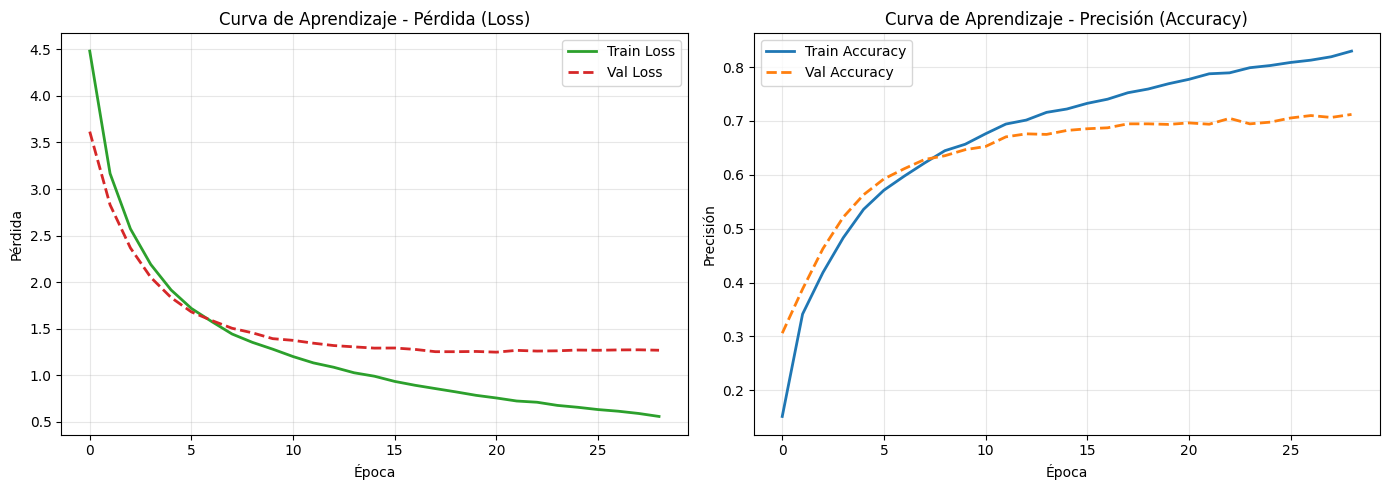


¡Gráfico 'learning_curve.png' generado y guardado exitosamente!


In [14]:
# --- Preparación de Tensores para PyTorch ---
print("Transformando datos para PyTorch...")
X_train_transformed = preprocessor.fit_transform(X_train_df)
X_test_transformed = preprocessor.transform(X_test_df)

# Convertir matriz rala de TfidfVectorizer a densa
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()

# Conversión a Tensores
X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Loaders para Entrenamiento y Validación (Test)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

input_dim = X_train_tensor.shape[1]
num_classes = len(np.unique(y_encoded))

parametros_a_probar = [
    {'hidden_dim': 128, 'lr': 0.001},
    {'hidden_dim': 256, 'lr': 0.001},
    {'hidden_dim': 256, 'lr': 0.0001}
]

resultados_mlp = []
best_history = None
best_val_loss_overall = float('inf')

print("\n--- Iniciando Experimentos de Deep Learning (MLP) ---")
for params in parametros_a_probar:
    print(f"\nIniciando entrenamiento con parámetros: {params}")
    model_mlp = SimpleMLP(input_dim=input_dim, num_classes=num_classes, hidden_dim=params['hidden_dim'])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_mlp.parameters(), lr=params['lr'])

    # Entrenamiento con 50 épocas y Early Stopping (patience=8)
    history = train_dl_model(model_mlp, train_loader, val_loader, criterion, optimizer, epochs=50, patience=8)

    final_val_loss = min(history['val_loss'])
    best_val_acc = max(history['val_acc'])

    resultados_mlp.append({
        'Hidden_Dim': params['hidden_dim'],
        'Learning_Rate': params['lr'],
        'Best_Val_Loss': final_val_loss,
        'Best_Val_Acc': best_val_acc
    })

    # Conservamos la mejor gráfica
    if final_val_loss < best_val_loss_overall:
        best_val_loss_overall = final_val_loss
        best_history = history

# Tabla de experimentos
df_mlp = pd.DataFrame(resultados_mlp)
print("\nResultados de Variación de Hiperparámetros (MLP):")
display(df_mlp)

# --- Gráficos de Curvas de Aprendizaje ---
if best_history:
    plt.figure(figsize=(14, 5))

    # Curva de Loss
    plt.subplot(1, 2, 1)
    plt.plot(best_history['train_loss'], label='Train Loss', color='#2ca02c', linewidth=2)
    plt.plot(best_history['val_loss'], label='Val Loss', color='#d62728', linewidth=2, linestyle='--')
    plt.title('Curva de Aprendizaje - Pérdida (Loss)')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Curva de Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(best_history['train_acc'], label='Train Accuracy', color='#1f77b4', linewidth=2)
    plt.plot(best_history['val_acc'], label='Val Accuracy', color='#ff7f0e', linewidth=2, linestyle='--')
    plt.title('Curva de Aprendizaje - Precisión (Accuracy)')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('learning_curve.png', dpi=300)
    plt.show()
    print("\n¡Gráfico \'learning_curve.png\' generado y guardado exitosamente!")